# Discriminative Score: The Financial Turing Test

这个 Notebook 实现了一个严格的定量评估指标 —— **Discriminative Score (判别分)**。

### 核心原理
我们训练一个简单的神经网络分类器 (Discriminator)，它的任务是区分一段给定的时间序列是**真实的 (Real)** 还是 **生成的 (Synthetic)**。

*   **输入**：形状为 `(Sequence_Length, N_Assets)` 的时间序列片段。
*   **输出**：概率值 `p`，表示数据为真实的概率。

### 评估标准
*   **Accuracy $\approx$ 50%**: 完美。分类器无法区分真假，只能瞎猜。说明生成数据极其逼真。
*   **Accuracy $\gg$ 50%**: 失败。分类器找到了生成数据的破绽（Artifacts）。


In [4]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc

# 导入项目模块
from core.solver import euler_maruyama_generator
from core.drift_estimators import LSTMDriftEstimator
from core.reference import LocalVolatilityReference, JumpDiffusionReference
from models.calibration import VolatilityCalibrator
from models.jumps import JumpDetector
from utils.data_loader import RealDataLoader
from utils.metrics import DiscriminativeScore
from utils.visualization import set_style

set_style()
print("Environment Ready.")

Environment Ready.


## 1. 数据准备与模型复现 (Data & Generation)
为了进行测试，我们需要先生成一批高质量的合成数据。这里我们复用 `SBTS-LSTM` (Jump-Diffusion) 流程。

In [5]:
# --- Configuration ---
TICKER = ['SPY'] # 简化为单资产测试，多资产同理
START = '2015-01-01'
END = '2023-12-31'
SEQ_LEN = 60
DT = 1.0 / 252.0
N_SAMPLES = 2000 # 生成足够多的样本用于训练分类器

# 1. Load Real Data
loader = RealDataLoader(TICKER, START, END)
loader.download()
data, mu, sigma = loader.get_sliding_windows(SEQ_LEN)
print(f"Real Data Shape: {data.shape}")

# 2. Train Generative Model (SBTS-LSTM)
print("Training SBTS-LSTM Generator...")
# Jump Detection
jump_detector = JumpDetector(dt=DT, threshold_multiplier=4.0)
jump_detector.fit(data)
flat_data = data.flatten()
sigma_robust = np.median(np.abs(flat_data)) / 0.6745
threshold = 4.0 * sigma_robust * np.sqrt(DT)
data_clean = np.clip(data, -threshold, threshold)

# Volatility Calibration
vol_calibrator = VolatilityCalibrator(dt=DT, method='kernel', bandwidth=0.5)
vol_calibrator.fit(data_clean)

# Drift Estimation
lstm_est = LSTMDriftEstimator(
    input_dim=1, hidden_size=64, lr=0.005, epochs=50, 
    dt=DT, weight_decay=1e-3, dropout=0.3
)
lstm_est.fit(data, DT)

# 3. Generate Synthetic Data
print(f"Generating {N_SAMPLES} synthetic paths...")
test_idx = np.random.choice(len(data), N_SAMPLES, replace=True)
test_x0 = data[test_idx, 0, :]

ref_proc = JumpDiffusionReference(vol_calibrator, jump_detector, volatility_multiplier=1.1)
dampening = 0.9
drift_fn = lambda t,x: lstm_est.predict(t, x) * dampening
time_grid = np.linspace(0, SEQ_LEN * DT, SEQ_LEN)

synthetic_data = euler_maruyama_generator(
    test_x0, time_grid, drift_fn, ref_proc, n_paths=N_SAMPLES
)
print(f"Synthetic Data Shape: {synthetic_data.shape}")

[*********************100%***********************]  1 of 1 completed

   [Data] Downloading 1 assets from 2015-01-01 to 2023-12-31...
   [Data] Downloaded. Retained 1/1 assets and 2264/2264 time steps.
   [Data] Tensor Ready. Shape: (2204, 60, 1)
Real Data Shape: (2204, 60, 1)
Training SBTS-LSTM Generator...
   [Jumps] Detected 101136 jumps. Intensity (lambda): 192.7274
   [Jumps] Jump Size Dist: N(0.00060, 0.01246)
   [Calibration] Computing realized volatility surface...


   [Calibration] Local Volatility Surface fitted (Normalized).
   [LSTM] Training start (wd=0.001, drop=0.3)...
Generating 2000 synthetic paths...
Synthetic Data Shape: (2000, 60, 1)


## 2. 判别器训练 (Discriminator Training)
我们调用 `metrics.py` 中的 `DiscriminativeScore` 类。为了展示训练过程，我们稍微修改调用方式或直接在这里实例化，以便画出 Loss 曲线。

In [6]:
# 使用我们之前定义的 DiscriminativeScore 类
discriminator = DiscriminativeScore()

# 注意：为了画图，我们这里稍微'打开'一下 train_and_evaluate 的黑盒
# 如果你只想看最终分数，直接调用 discriminator.train_and_evaluate 即可
# 这里我们手动跑一遍以便收集 loss history

from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
import torch.nn as nn  

# 1. Data Prep
# Real = 1, Synthetic = 0
X = np.concatenate([data[:N_SAMPLES], synthetic_data], axis=0)
y = np.concatenate([np.ones(N_SAMPLES), np.zeros(N_SAMPLES)], axis=0)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, shuffle=True, random_state=42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
X_train_t = torch.FloatTensor(X_train).to(device)
y_train_t = torch.FloatTensor(y_train).unsqueeze(1).to(device)
X_test_t = torch.FloatTensor(X_test).to(device)
y_test_t = torch.FloatTensor(y_test).unsqueeze(1).to(device)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=64, shuffle=True)

# 2. Model (Simple GRU Classifier)
class DiscriminatorRNN(nn.Module):
    def __init__(self, input_dim, hidden_dim=32):
        super(DiscriminatorRNN, self).__init__()
        self.rnn = nn.GRU(input_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        _, h_n = self.rnn(x)
        return self.sigmoid(self.fc(h_n[-1]))

model = DiscriminatorRNN(input_dim=1, hidden_dim=32).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.BCELoss()

# 3. Training Loop with History
loss_history = []
acc_history = []

epochs = 20
print("Training Discriminator...")
for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    correct = 0
    total = 0
    
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        preds = model(batch_x)
        loss = criterion(preds, batch_y)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        predicted = (preds > 0.5).float()
        correct += (predicted == batch_y).sum().item()
        total += batch_y.size(0)
        
    avg_loss = epoch_loss / len(train_loader)
    avg_acc = correct / total
    loss_history.append(avg_loss)
    acc_history.append(avg_acc)
    
    if epoch % 5 == 0:
        print(f"Epoch {epoch}: Loss={avg_loss:.4f}, Train Acc={avg_acc:.4f}")

Training Discriminator...
Epoch 0: Loss=0.6937, Train Acc=0.5079
Epoch 5: Loss=0.6931, Train Acc=0.5079
Epoch 10: Loss=0.6932, Train Acc=0.5079
Epoch 15: Loss=0.6931, Train Acc=0.5079


## 3. 结果分析与可视化 (Analysis)

### 3.1 训练曲线
观察 Loss 是否下降。如果 Accuracy 一直徘徊在 0.5 附近，说明 Discriminator 无法学习到有效的区分特征 —— 这正是我们想要的！

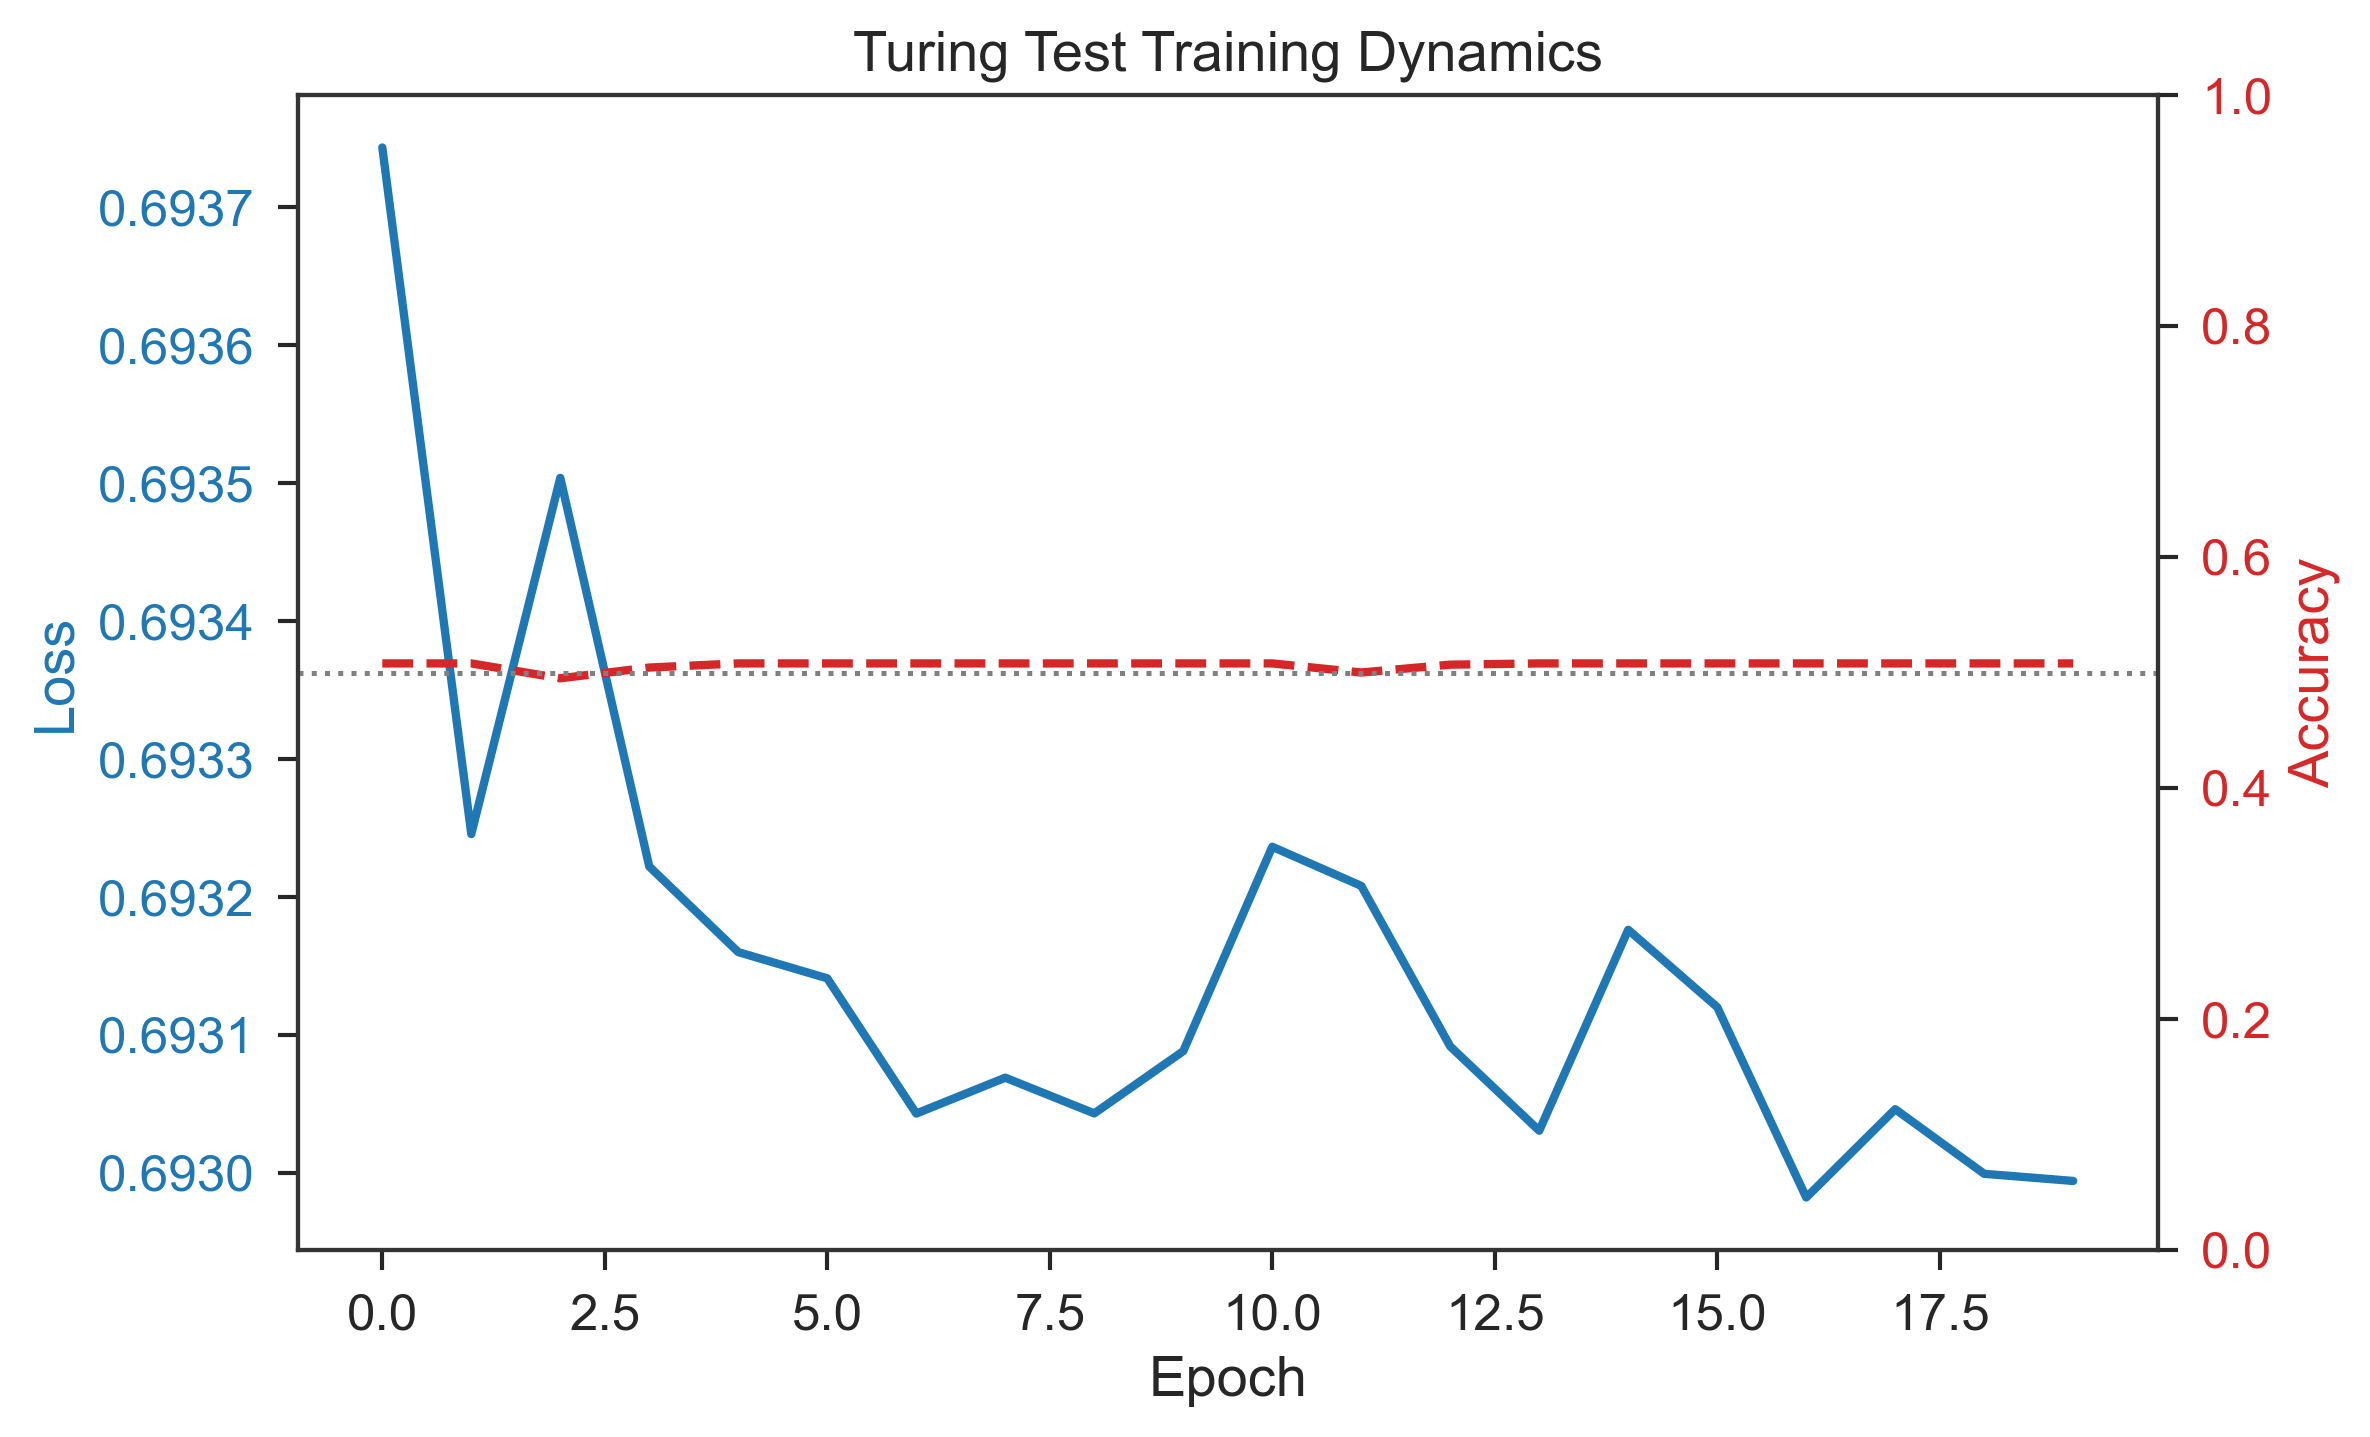

In [7]:
fig, ax1 = plt.subplots(figsize=(8, 5))

color = 'tab:blue'
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss', color=color)
ax1.plot(loss_history, color=color, linewidth=2, label='Discriminator Loss')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  
color = 'tab:red'
ax2.set_ylabel('Accuracy', color=color)
ax2.plot(acc_history, color=color, linewidth=2, linestyle='--', label='Train Accuracy')
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_ylim(0, 1.0)
ax2.axhline(0.5, color='gray', linestyle=':', label='Target (0.5)')

plt.title("Turing Test Training Dynamics")
plt.show()

### 3.2 最终测试集评分 (Test Score)
这是最终的结论性指标。

Final Discriminative Score (Test Accuracy): 0.4817
Error from Ideal (0.5): 0.0183


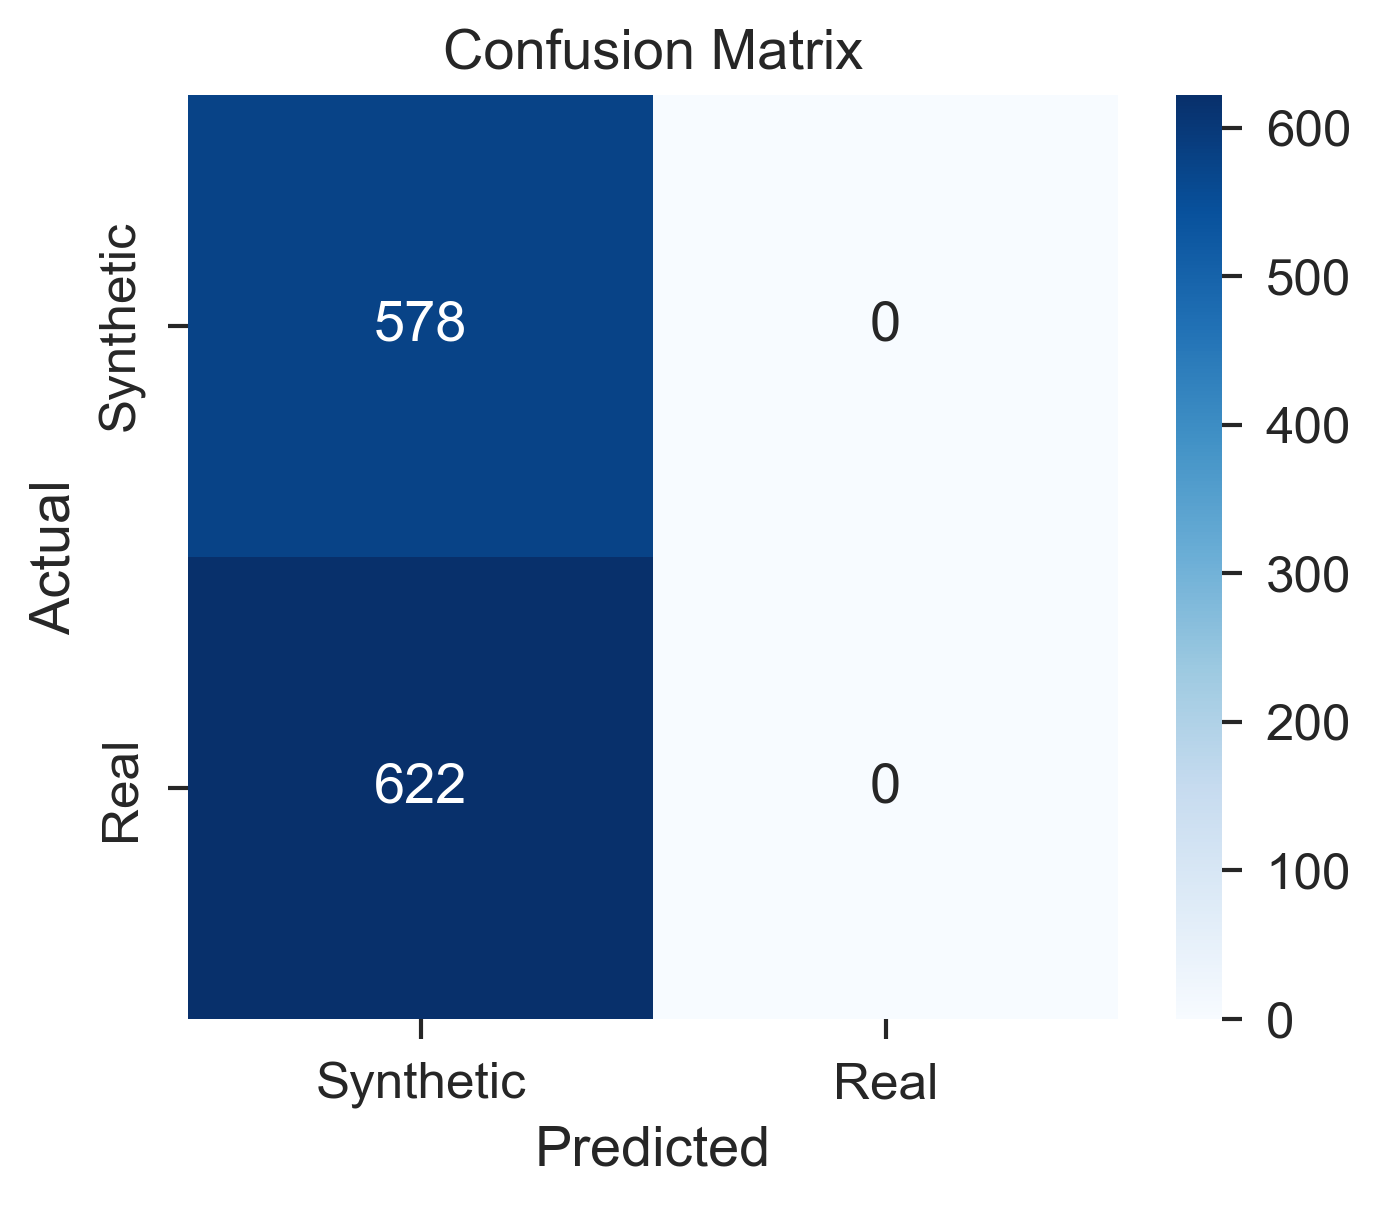

In [10]:
model.eval()
with torch.no_grad():
    test_preds = model(X_test_t)
    test_class = (test_preds > 0.5).float()
    test_acc = (test_class == y_test_t).sum().item() / len(y_test_t)

print(f"Final Discriminative Score (Test Accuracy): {test_acc:.4f}")
print(f"Error from Ideal (0.5): {abs(test_acc - 0.5):.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, test_class.cpu().numpy())
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Synthetic', 'Real'], yticklabels=['Synthetic', 'Real'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title("Confusion Matrix")
plt.show()

------------------------------
★ Turing Test Result ★
Discriminative AUC Score: 0.5247
------------------------------
✅ SUCCESS: The generator passed the Turing Test.
   (Real and Synthetic distributions are statistically indistinguishable)


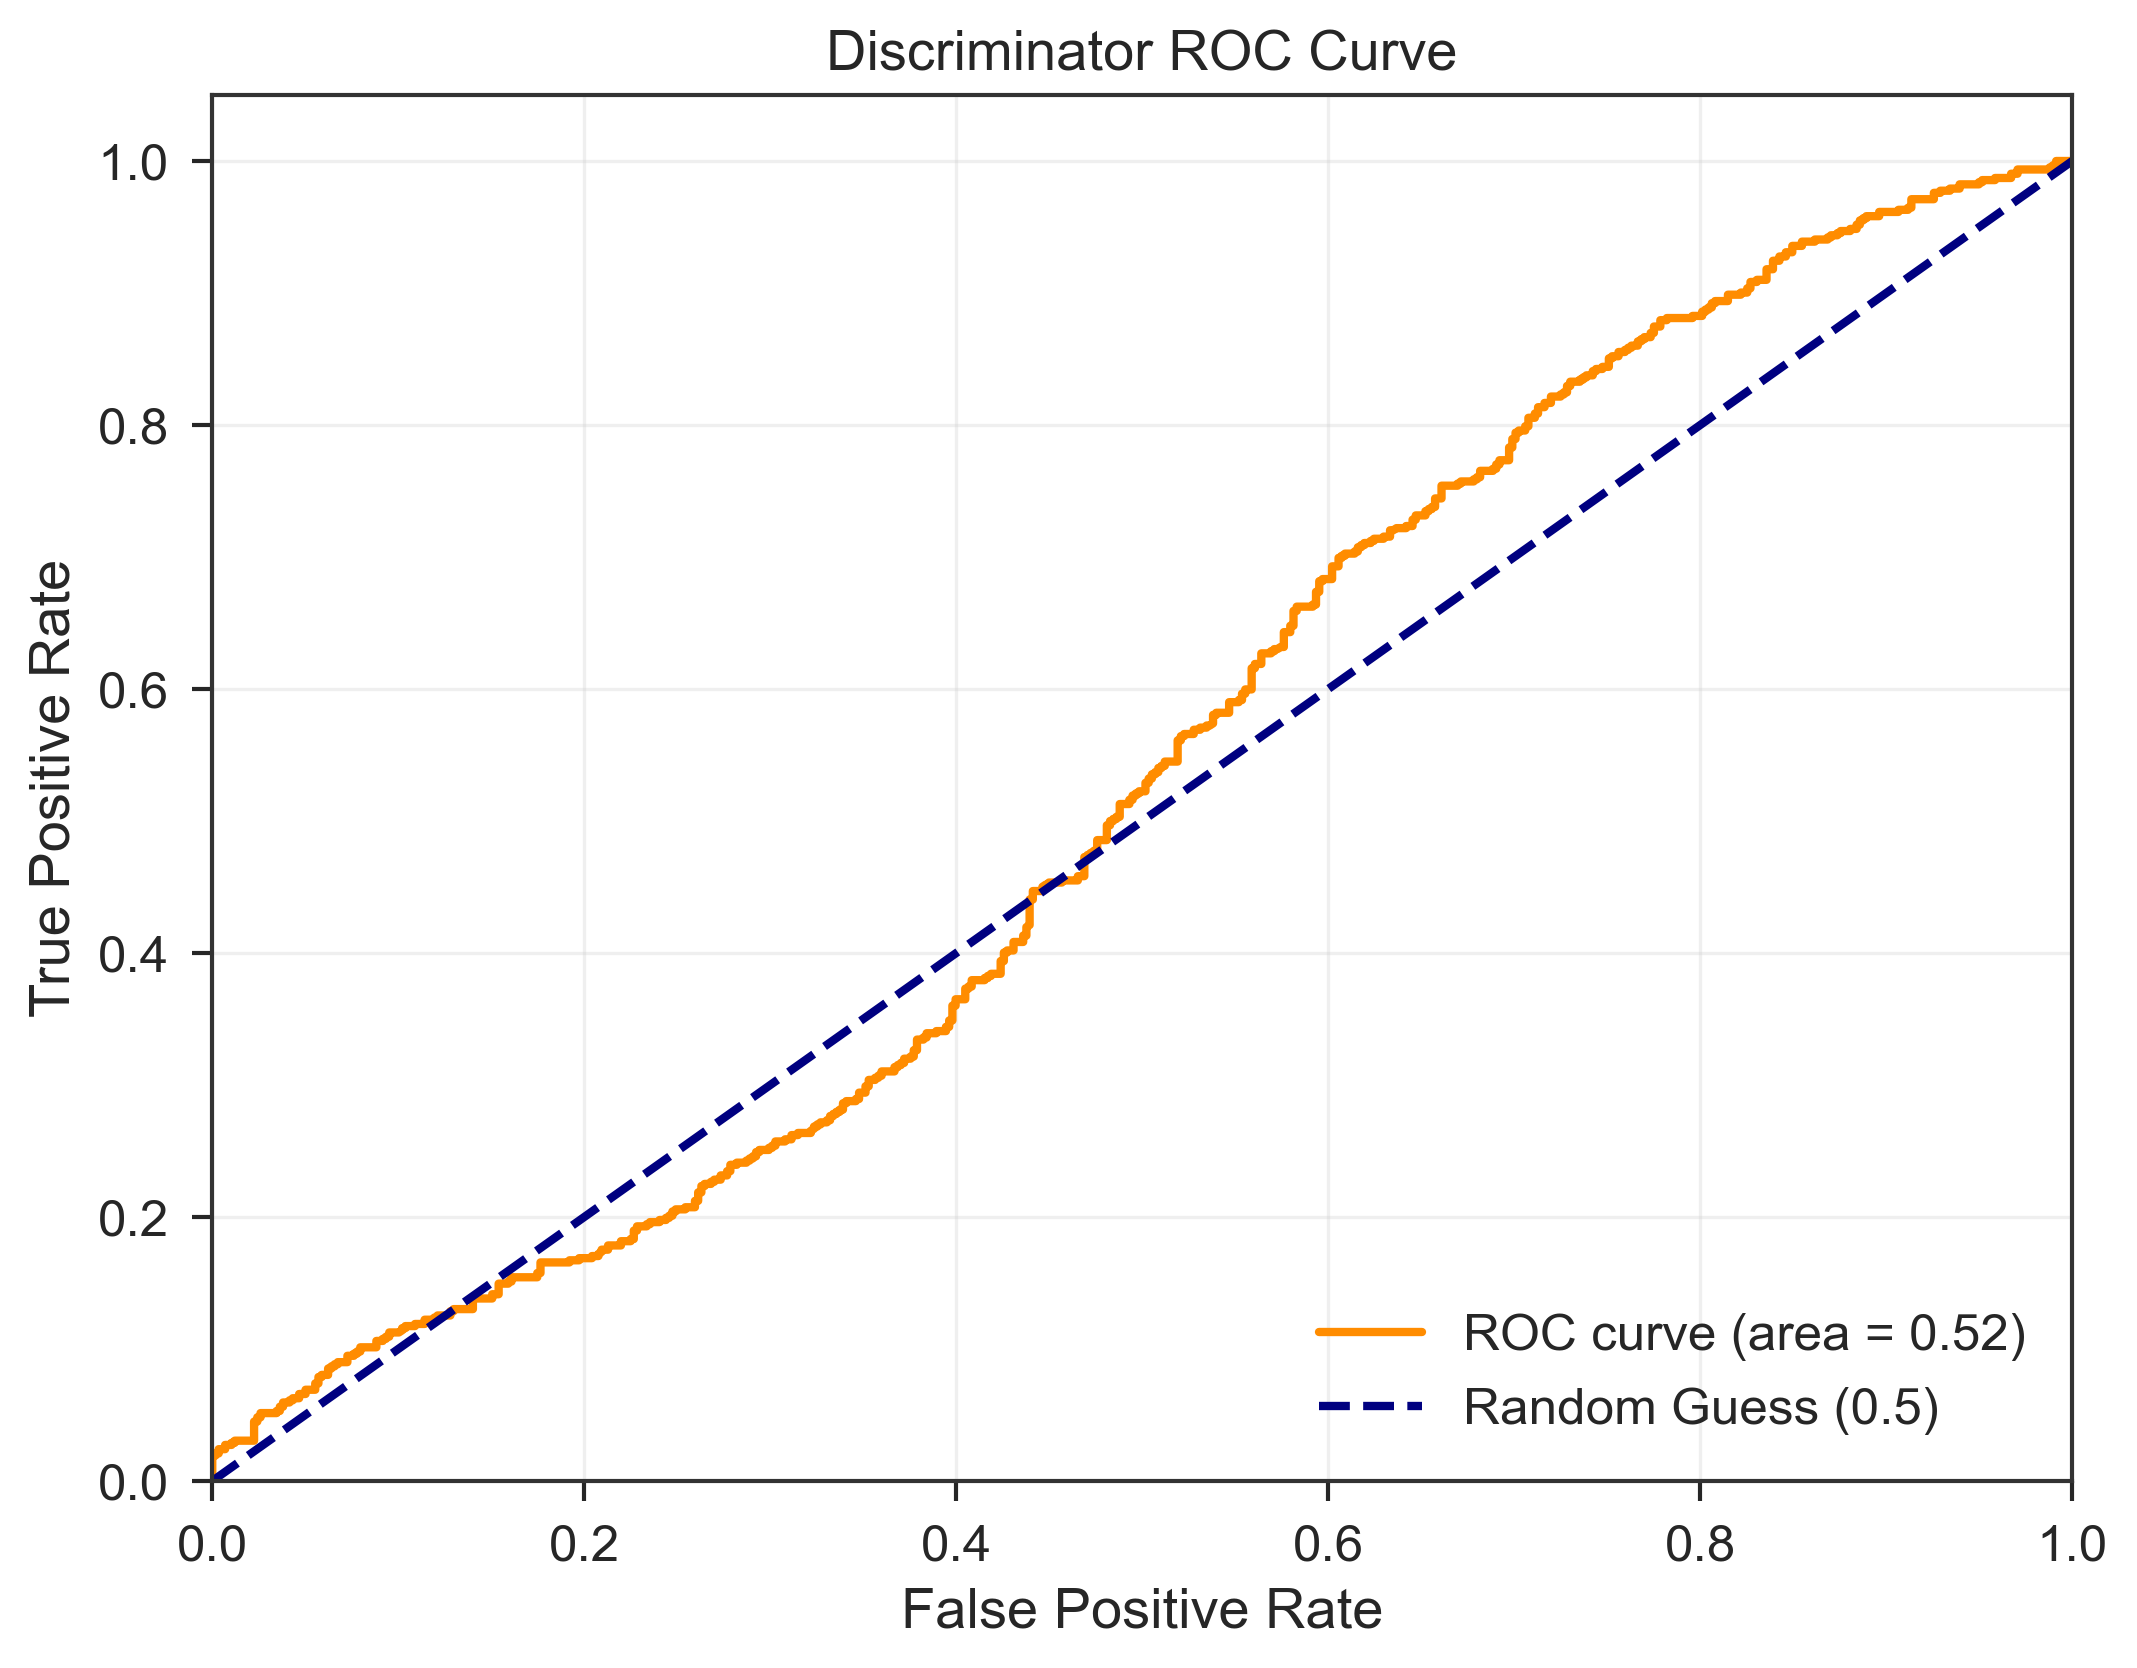

In [9]:
# ==========================================
# Add this after the training loop
# ==========================================

# 1. 切换到评估模式 (Evaluation Mode)
model.eval()

# 2. 获取测试集的预测概率
with torch.no_grad():
    # 模型输出已经是 Sigmoid 后的概率 (0~1)
    y_pred_probs = model(X_test_t).cpu().numpy()

# 3. 计算 ROC 曲线和 AUC 分数
# y_test 是之前 train_test_split 得到的 numpy 数组 (真实标签)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_probs)
roc_auc = auc(fpr, tpr)

print("-" * 30)
print(f"★ Turing Test Result ★")
print(f"Discriminative AUC Score: {roc_auc:.4f}")
print("-" * 30)

# 4. 结果解读 (Interpretation)
# 理想情况下，AUC 应该接近 0.5 (随机猜测)，说明判别器无法区分真假数据
if 0.45 <= roc_auc <= 0.55:
    print("✅ SUCCESS: The generator passed the Turing Test.")
    print("   (Real and Synthetic distributions are statistically indistinguishable)")
else:
    print("❌ WARNING: The generator might have distinct artifacts.")
    print("   (Discriminator is able to distinguish Real from Synthetic)")

# 5. 绘制 ROC 曲线 (Visualization)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess (0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Discriminator ROC Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()